# Does the recommender actually work?

This notebook explains and reproduces the evaluation behind the numbers in
[`docs/metrics.json`](../docs/metrics.json).

**The model.** ALS (alternating least squares) trained on six months of real H&M
purchases ([H&M Personalized Fashion Recommendations](https://www.kaggle.com/competitions/h-and-m-personalized-fashion-recommendations), Kaggle).
It learns **128 numbers per garment** purely from *who bought what* — no images,
no descriptions, no categories. Garments bought by the same people end up with
similar numbers.

**What is being measured.** Not the textbook evaluation. The app has no H&M
customers: every visitor is a stranger whose taste is built by averaging the
vectors of the garments they swipe right on. So the evaluation simulates exactly
that — take a customer the model never saw shopping in the final two weeks,
treat their first 3 purchases as swipes, build the style vector the same way the
live feed does, and check whether the rest of what they bought comes back in
the top 12.

All logic lives in `backend/ml/` (and is unit-tested); this notebook only
narrates and draws.

In [1]:
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.colors import LinearSegmentedColormap

ROOT = Path.cwd().parent
sys.path.insert(0, str(ROOT / "backend"))

from ml.matrix import build_interaction_matrix
from ml.ranking import dedupe_by_group, rank_by_similarity
from ml.train import train_als

# Chart style: light surface, recessive hairline axes, one accent colour.
SURFACE, INK, INK_2, MUTED = "#fcfcfb", "#0b0b0b", "#52514e", "#898781"
GRID, AXIS, WASH = "#e1e0d9", "#c3c2b7", "#f0efec"
BLUE, ORANGE = "#2a78d6", "#eb6834"  # colour-blind-safe pair (validated)
BLUE_RAMP = ["#cde2fb", "#9ec5f4", "#6da7ec", "#3987e5", "#256abf", "#184f95", "#0d366b"]

plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "font.family": "sans-serif", "font.sans-serif": ["Segoe UI", "DejaVu Sans"],
    "font.size": 10, "text.color": INK, "axes.labelcolor": INK_2,
    "axes.edgecolor": AXIS, "axes.linewidth": 1,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.titlesize": 11, "axes.titleweight": "semibold", "axes.titlelocation": "left",
    "xtick.color": MUTED, "ytick.color": MUTED, "xtick.labelcolor": INK_2, "ytick.labelcolor": INK_2,
    "grid.color": GRID, "grid.linewidth": 1, "grid.linestyle": "-",
    "legend.frameon": False, "figure.dpi": 110,
})

metrics = json.loads((ROOT / "docs" / "metrics.json").read_text(encoding="utf-8"))
print(f"generated {metrics['generated_on']}")
print(f"{metrics['n_articles']:,} garments ({metrics['n_designs']:,} distinct designs), "
      f"{metrics['n_train_rows']:,} training purchases")
print(f"{metrics['n_visitors']:,} simulated visitors, seeded with "
      f"{metrics['cold_start_likes']} likes, scored on the top {metrics['k']}")

generated 2026-10-08
5,000 garments (2,547 distinct designs), 4,048,415 training purchases
8,959 simulated visitors, seeded with 3 likes, scored on the top 12


## 1. The data, split by time

The model learns from purchases up to 8 September 2020 and is tested on the
14 days after — purchases it never saw. Splitting by **date** rather than at
random matters: a random split would let the model learn from a customer's
September purchases and be "tested" on their July ones, i.e. see the future.

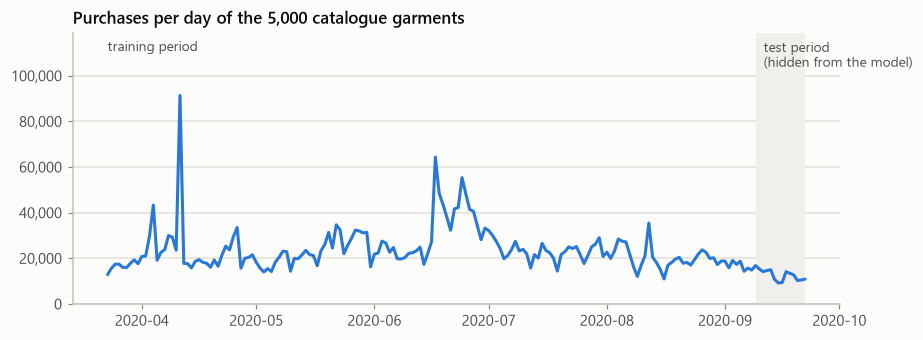

training: 4,048,415 purchases, 23 Mar – 08 Sep 2020
test:     177,357 purchases, 09 Sep – 22 Sep 2020


In [2]:
train = pd.read_parquet(ROOT / "data" / "train.parquet")
holdout = pd.read_parquet(ROOT / "data" / "holdout.parquet")
subset = pd.read_csv(ROOT / "data" / "subset.csv", dtype=str)

daily_train = train.groupby("t_dat").size()
daily_holdout = holdout.groupby("t_dat").size()
daily = pd.concat([daily_train, daily_holdout])

fig, ax = plt.subplots(figsize=(9, 3.2))
ax.axvspan(daily_holdout.index.min(), daily_holdout.index.max(), color=WASH, lw=0)
ax.plot(daily.index, daily.values, color=BLUE, lw=2, solid_joinstyle="round", solid_capstyle="round")
ax.grid(axis="y")
ax.set_axisbelow(True)
top = daily.max() * 1.3  # headroom so the labels clear the spikes
ax.set_ylim(0, top)
ax.yaxis.set_major_formatter(lambda v, _: f"{v:,.0f}")
ax.set_title("Purchases per day of the 5,000 catalogue garments")
ax.text(daily_holdout.index.min(), top * 0.97, "  test period\n  (hidden from the model)",
        va="top", ha="left", color=INK_2, fontsize=9)
ax.text(daily_train.index.min(), top * 0.97, "training period", va="top", color=INK_2, fontsize=9)
plt.show()
print(f"training: {len(train):,} purchases, {daily_train.index.min():%d %b} – {daily_train.index.max():%d %b %Y}")
print(f"test:     {len(holdout):,} purchases, {daily_holdout.index.min():%d %b} – {daily_holdout.index.max():%d %b %Y}")

## 2. What the model trains on: a very empty grid

Purchases become a grid — one row per customer, one column per garment, each
cell the number of times that customer bought that garment. Almost every cell
is empty, and the filled ones are almost all **1**: repeat purchases are rare.
That is why shrinking repeat counts (log scaling) made no measurable
difference in the evaluation below.

612,985 customers x 5,000 garments = 3,064,925,000 cells
filled: 3,507,800 (0.11%); largest count: 80


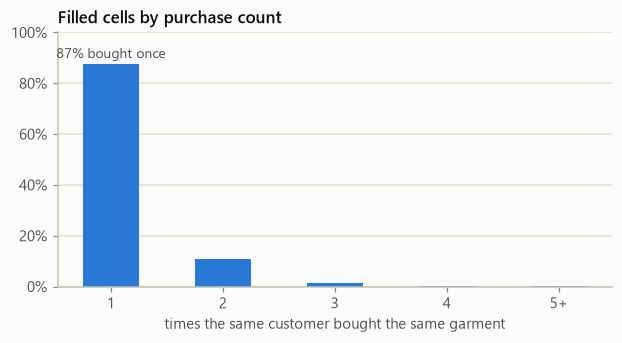

In [3]:
matrix, mapping = build_interaction_matrix(train)
n_cells = matrix.shape[0] * matrix.shape[1]
print(f"{matrix.shape[0]:,} customers x {matrix.shape[1]:,} garments = {n_cells:,} cells")
print(f"filled: {matrix.nnz:,} ({matrix.nnz / n_cells:.2%}); largest count: {int(matrix.data.max())}")

counts = matrix.data.astype(int)
labels = ["1", "2", "3", "4", "5+"]
shares = [np.mean(counts == n) for n in (1, 2, 3, 4)] + [np.mean(counts >= 5)]

fig, ax = plt.subplots(figsize=(6.5, 3))
ax.bar(labels, shares, width=0.5, color=BLUE)
ax.set_ylim(0, 1)
ax.grid(axis="y")
ax.set_axisbelow(True)
ax.yaxis.set_major_formatter(lambda v, _: f"{v:.0%}")
ax.set_xlabel("times the same customer bought the same garment")
ax.set_title("Filled cells by purchase count")
ax.annotate(f"{shares[0]:.0%} bought once", (0, shares[0]), xytext=(0, 4),
            textcoords="offset points", ha="center", color=INK_2, fontsize=9)
plt.show()

## 3. Results

Three competitors recommend 12 garments to each of the simulated visitors:

- **Random** — a sanity check. Losing to it would mean something is broken.
- **Best-sellers** — the same 12 most-bought garments for everyone. Hard to
  beat in fashion, and what the app shows before a visitor has 3 likes.
- **ALS, 128 numbers** — the model the app ships.

Each is scored three ways (higher is better):

- **recall@12** — what share of the visitor's remaining purchases appeared in the 12.
- **MAP@12** — the same, but hits near the top of the list count for more.
- **new designs only** — recall counting only garments of a *design the visitor
  had not liked*. Suggesting another colour of something you just liked is a
  correct guess, but an easy one; this score removes it.

All recommenders are scored the way the feed serves: already-liked garments
removed, one colour per design. Error bars are 95% bootstrap intervals —
re-drawing the visitors at random 1,000 times shows how much each score
depends on which visitors happened to be in the test.

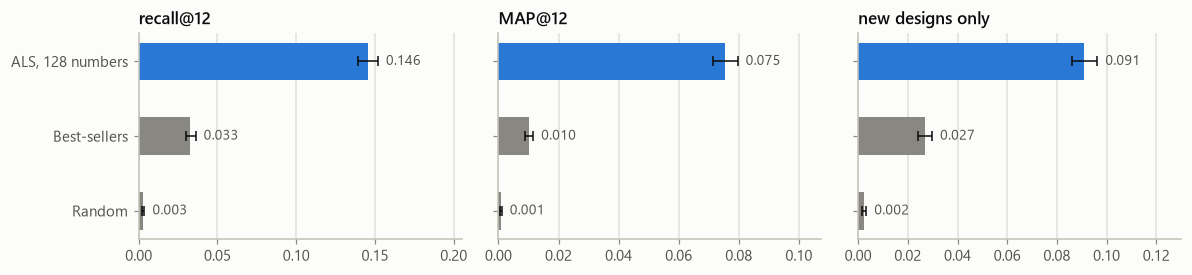

        recall@12: model 0.146 vs best-sellers 0.033  (4.5x)
           MAP@12: model 0.075 vs best-sellers 0.010  (7.4x)
 new designs only: model 0.091 vs best-sellers 0.027  (3.4x)


In [4]:
SHIPPED = "als-128f-v1"
competitors = {
    "Random": metrics["baselines"]["random"],
    "Best-sellers": metrics["baselines"]["popularity"],
    "ALS, 128 numbers": metrics["models"][SHIPPED],
}
panels = [("recall_at_k", "recall_ci95", "recall@12"),
          ("map_at_k", "map_ci95", "MAP@12"),
          ("new_design_recall_at_k", "new_design_recall_ci95", "new designs only")]

fig, axes = plt.subplots(1, 3, figsize=(11, 2.6), sharey=True)
names = list(competitors)
for ax, (key, ci_key, title) in zip(axes, panels):
    values = [competitors[n][key] for n in names]
    lows = [values[i] - competitors[n][ci_key][0] for i, n in enumerate(names)]
    highs = [competitors[n][ci_key][1] - values[i] for i, n in enumerate(names)]
    colours = [MUTED, MUTED, BLUE]
    ax.barh(names, values, height=0.5, color=colours)
    ax.errorbar(values, names, xerr=[lows, highs], fmt="none", ecolor=INK, elinewidth=1, capsize=3)
    for i, n in enumerate(names):
        ax.text(competitors[n][ci_key][1], i, f"  {values[i]:.3f}", va="center", color=INK_2, fontsize=9)
    ax.set_xlim(0, max(c[ci_key][1] for c in competitors.values()) * 1.35)
    ax.grid(axis="x")
    ax.set_axisbelow(True)
    ax.set_title(title)
plt.tight_layout()
plt.show()

model, pop = competitors["ALS, 128 numbers"], competitors["Best-sellers"]
for key, _, title in panels:
    print(f"{title:>17}: model {model[key]:.3f} vs best-sellers {pop[key]:.3f}  ({model[key] / pop[key]:.1f}x)")

The full table, including every model size tried and both ways of counting
repeat purchases. The "vs best-sellers" columns are **paired**: both are scored
on the same visitors and the gap is measured visitor by visitor, so an interval
entirely above zero means the win is real, not luck.

In [5]:
def interval(pair):
    return f"{pair[0]:.3f} – {pair[1]:.3f}"

rows = []
for name, entry in [("random", metrics["baselines"]["random"]),
                    ("best-sellers", metrics["baselines"]["popularity"]),
                    *metrics["models"].items()]:
    gap = entry.get("vs_popularity")
    rows.append({
        "approach": name,
        "recall@12": f"{entry['recall_at_k']:.3f}",
        "95% interval": interval(entry["recall_ci95"]),
        "MAP@12": f"{entry['map_at_k']:.3f}",
        "new designs": f"{entry['new_design_recall_at_k']:.3f}",
        "recall vs best-sellers": f"{gap['recall_diff']:+.3f} ({interval(gap['recall_diff_ci95'])})" if gap else "",
    })
pd.DataFrame(rows).set_index("approach")

,recall@12,95% interval,MAP@12,new designs,recall vs best-sellers
approach,,,,,
random,0.003,0.002 – 0.004,0.001,0.002,
best-sellers,0.033,0.030 – 0.036,0.010,0.027,
als-32f-v1,0.118,0.113 – 0.124,0.058,0.078,+0.085 (0.079 – 0.092)
als-64f-v1,0.135,0.129 – 0.142,0.068,0.085,+0.103 (0.096 – 0.110)
als-128f-v1,0.146,0.139 – 0.152,0.075,0.091,+0.113 (0.105 – 0.120)
als-256f-v1,0.120,0.114 – 0.126,0.070,0.065,+0.087 (0.080 – 0.094)
als-32f-log-v1,0.117,0.112 – 0.123,0.058,0.078,+0.085 (0.079 – 0.091)
als-64f-log-v1,0.134,0.128 – 0.140,0.067,0.083,+0.101 (0.094 – 0.108)
als-128f-log-v1,0.146,0.139 – 0.152,0.076,0.090,+0.113 (0.106 – 0.120)


## 4. How many numbers per garment?

More numbers let the model capture finer distinctions of taste — up to a
point. Past it, the spare capacity gets spent memorising one-off coincidences
in the training data (**overfitting**), which don't repeat, so predictions on
new behaviour get worse.

That is exactly the shape below: scores climb from 32 to 128 numbers, then
fall at 256. The fall is steepest on *new designs only* — the 256 model still
finds "another colour of what you liked", but generalises taste to unseen
designs worse. Raw and log-scaled purchase counts track each other closely.

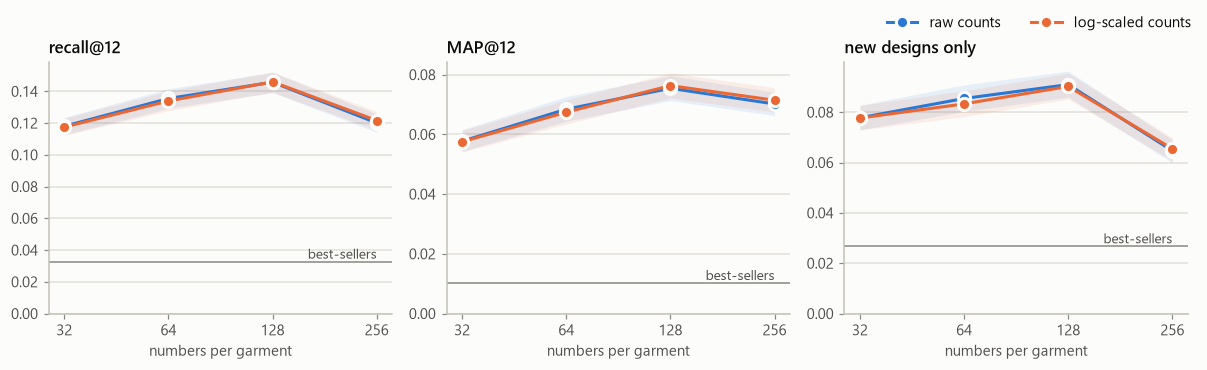

In [6]:
sizes = [32, 64, 128, 256]
variants = [("raw counts", "", BLUE), ("log-scaled counts", "-log", ORANGE)]

fig, axes = plt.subplots(1, 3, figsize=(11, 3.2))
for ax, (key, ci_key, title) in zip(axes, panels):
    for label, suffix, colour in variants:
        entries = [metrics["models"][f"als-{s}f{suffix}-v1"] for s in sizes]
        values = [e[key] for e in entries]
        ax.fill_between(sizes, [e[ci_key][0] for e in entries], [e[ci_key][1] for e in entries],
                        color=colour, alpha=0.1, lw=0)
        ax.plot(sizes, values, color=colour, lw=2, marker="o", markersize=8,
                markeredgecolor=SURFACE, markeredgewidth=2, label=label)
    baseline = metrics["baselines"]["popularity"][key]
    ax.axhline(baseline, color=MUTED, lw=1)
    ax.text(sizes[-1], baseline, "best-sellers", va="bottom", ha="right", color=INK_2, fontsize=9)
    ax.set_xscale("log", base=2)
    ax.set_xticks(sizes, [str(s) for s in sizes])
    ax.minorticks_off()
    ax.set_ylim(0)
    ax.grid(axis="y")
    ax.set_axisbelow(True)
    ax.set_xlabel("numbers per garment")
    ax.set_title(title)
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper right", ncol=2, bbox_to_anchor=(1, 1.06))
plt.tight_layout()
plt.show()

## 5. Is it just recommending other colours?

H&M sells most designs in several colours (5,000 garments here are only 2,547
designs). A visitor who liked the black jeans may well have bought the blue
ones too, and the model finds those easily. Comparing *all purchases* with
*new designs only* shows how much of the win survives without that shortcut:
the margin over best-sellers shrinks, but the model still finds new designs
over 3 times as often.

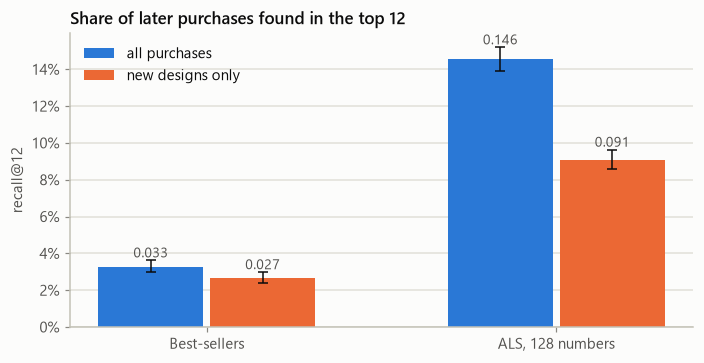

In [7]:
groups_names = ["Best-sellers", "ALS, 128 numbers"]
series = [("all purchases", "recall_at_k", "recall_ci95", BLUE),
          ("new designs only", "new_design_recall_at_k", "new_design_recall_ci95", ORANGE)]
x = np.arange(len(groups_names))
width = 0.3

fig, ax = plt.subplots(figsize=(6.5, 3.4))
for i, (label, key, ci_key, colour) in enumerate(series):
    offset = (i - 0.5) * (width + 0.02)  # small surface gap between the paired bars
    values = [competitors[g][key] for g in groups_names]
    errors = [[v - competitors[g][ci_key][0] for g, v in zip(groups_names, values)],
              [competitors[g][ci_key][1] - v for g, v in zip(groups_names, values)]]
    ax.bar(x + offset, values, width, color=colour, label=label)
    ax.errorbar(x + offset, values, yerr=errors, fmt="none", ecolor=INK, elinewidth=1, capsize=3)
    for xi, g, v in zip(x, groups_names, values):
        ax.text(xi + offset, competitors[g][ci_key][1], f"{v:.3f}", ha="center", va="bottom",
                color=INK_2, fontsize=9)
ax.set_xticks(x, groups_names)
ax.yaxis.set_major_formatter(lambda v, _: f"{v:.0%}")
ax.grid(axis="y")
ax.set_axisbelow(True)
ax.set_ylabel("recall@12")
ax.set_title("Share of later purchases found in the top 12")
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()

## 6. What the model learned

Nothing told the model what a shoe or a menswear shirt is. It only saw which
garments were bought by the same people. The cell below retrains the shipped
model (same data and random seed, about a minute) so its 128 numbers per
garment can be inspected.

In [8]:
vectors = train_als(matrix, factors=128)
catalog = subset.set_index("article_id").reindex(mapping.article_ids)
designs = catalog["product_code"].tolist()
unit = vectors / np.linalg.norm(vectors, axis=1, keepdims=True)
print(f"vectors: {vectors.shape[0]:,} garments x {vectors.shape[1]} numbers")

vectors: 5,000 garments x 128 numbers


### Garments bought by the same kind of shopper end up close together

Each cell is the average **similarity** (cosine: 1 = pointing the same way,
0 = unrelated) between garments from two H&M store sections. The bright
diagonal for Menswear and Sport means the model separated those shoppers from
everyone else — from purchases alone. (Baby/Children, with only 11 garments,
is left out.)

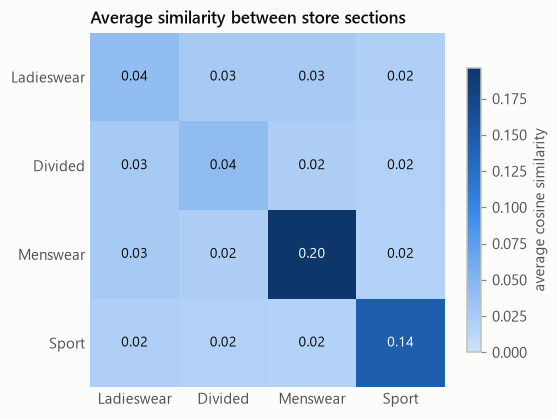

index_group_name
Ladieswear       3399
Divided          1169
Menswear          232
Sport             189
Baby/Children      11


In [9]:
sections = ["Ladieswear", "Divided", "Menswear", "Sport"]
section_of = catalog["index_group_name"].to_numpy()
grid = np.zeros((len(sections), len(sections)))
for i, a in enumerate(sections):
    for j, b in enumerate(sections):
        sims = unit[section_of == a] @ unit[section_of == b].T
        if a == b:
            sims = sims[~np.eye(len(sims), dtype=bool)]  # ignore each garment vs itself
        grid[i, j] = sims.mean()

cmap = LinearSegmentedColormap.from_list("blue", BLUE_RAMP)
fig, ax = plt.subplots(figsize=(5.2, 4.2))
image = ax.imshow(grid, cmap=cmap, vmin=0)
ax.set_xticks(range(len(sections)), sections)
ax.set_yticks(range(len(sections)), sections)
ax.tick_params(length=0)
for side in ax.spines.values():
    side.set_visible(False)
for i in range(len(sections)):
    for j in range(len(sections)):
        dark = grid[i, j] > grid.max() * 0.55
        ax.text(j, i, f"{grid[i, j]:.2f}", ha="center", va="center", fontsize=9,
                color="white" if dark else INK)
ax.set_title("Average similarity between store sections")
fig.colorbar(image, ax=ax, shrink=0.8, label="average cosine similarity")
plt.show()
print(catalog["index_group_name"].value_counts().to_string())

### A map of all 5,000 garments

128 numbers can't be drawn, so they are squashed to two with **PCA**
(principal component analysis), which keeps the two directions along which
garments differ most. Each panel highlights one category.

The two biggest directions the model found are *shoes vs everything else*
(across) and *accessories vs everything else* (downwards). Tops, bottoms
and dresses overlap in this squashed view — what separates them lives in the
other 126 directions, as the similarity scores above show.

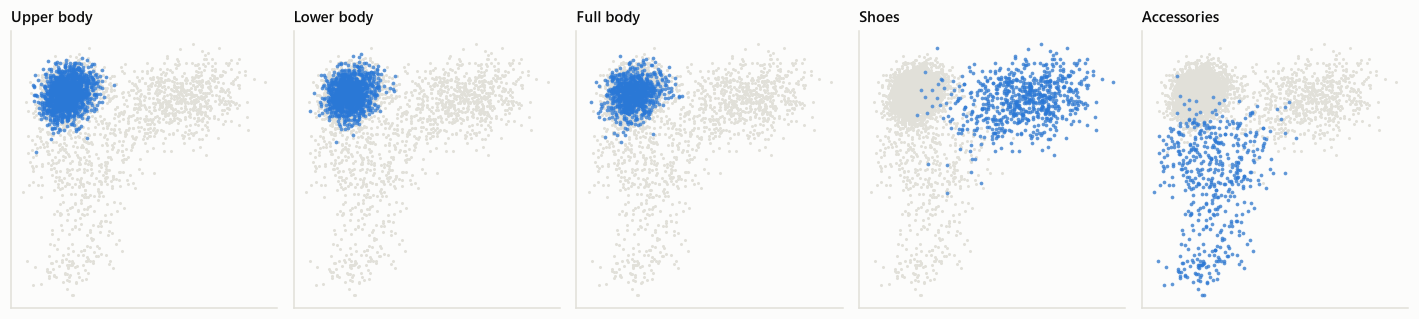

In [10]:
centred = unit - unit.mean(axis=0)
_, _, directions = np.linalg.svd(centred, full_matrices=False)
xy = centred @ directions[:2].T
category = catalog["product_group_name"].to_numpy()
categories = ["Garment Upper body", "Garment Lower body", "Garment Full body", "Shoes", "Accessories"]

fig, axes = plt.subplots(1, 5, figsize=(13, 3), sharex=True, sharey=True)
for ax, name in zip(axes, categories):
    ax.scatter(xy[:, 0], xy[:, 1], s=4, color=GRID, lw=0)
    mine = category == name
    ax.scatter(xy[mine, 0], xy[mine, 1], s=6, color=BLUE, lw=0, alpha=0.7)
    ax.set_title(name.replace("Garment ", ""), fontsize=10)
    ax.set_xticks([])
    ax.set_yticks([])
    for side in ax.spines.values():
        side.set_color(GRID)
plt.tight_layout()
plt.show()

### Nearest neighbours

The same calculation the live feed runs: rank all garments by similarity to
one liked garment. The closest matches are usually other colours of the same
design, so those are skipped here to show which *other designs* the model
links it with.

In [11]:
def neighbours(article_id: str, n: int = 6) -> pd.DataFrame:
    position = mapping.article_position(article_id)
    ranked = rank_by_similarity(vectors[position], vectors)
    ranked = ranked[[designs[p] != designs[position] for p in ranked]]  # other designs only
    ranked = dedupe_by_group(ranked, designs)[:n]
    similarity = unit[ranked] @ unit[position]
    return pd.DataFrame({
        "similarity": similarity.round(2),
        "name": catalog["prod_name"].to_numpy()[ranked],
        "type": catalog["product_type_name"].to_numpy()[ranked],
        "colour": catalog["colour_group_name"].to_numpy()[ranked],
        "section": catalog["index_group_name"].to_numpy()[ranked],
    }, index=pd.RangeIndex(1, len(ranked) + 1, name="rank"))

popularity = catalog["popularity"].astype(int)
examples = [popularity[catalog["product_group_name"] == group].idxmax()
            for group in ["Garment Lower body", "Shoes", "Accessories"]]
examples.append(popularity[catalog["index_group_name"] == "Menswear"].idxmax())

for article_id in examples:
    row = catalog.loc[article_id]
    print(f"\nLiked: {row['prod_name']} — {row['product_type_name']}, {row['colour_group_name']} ({row['index_group_name']})")
    display(neighbours(article_id))


Liked: Jade HW Skinny Denim TRS — Trousers, Black (Divided)


,similarity,name,type,colour,section
rank,,,,,
1,0.38,Jade HW Skinny Belt Denim TRS,Trousers,Black,Divided
2,0.30,Jade HW Skinny Button dnm,Trousers,Black,Divided
3,0.27,S. Skinny HW Ankle Star Consc,Trousers,Grey,Divided
4,0.26,Super Skinny HW ankle Star,Trousers,Black,Divided
5,0.22,Julia RW Skinny Denim TRS,Trousers,Black,Divided
6,0.22,Jade Trash HW Skinny Denim TRS,Trousers,Black,Divided



Liked: GLASSIG ESPADRILLE — Ballerinas, Black (Ladieswear)


,similarity,name,type,colour,section
rank,,,,,
1,0.69,Maggi espadrille,Flat shoe,White,Ladieswear
2,0.63,Mina espadrill,Flat shoe,Black,Divided
3,0.62,Lorenzo espadrille,Flat shoe,Black,Ladieswear
4,0.56,OL CELESTE PQ Espadrille,Other shoe,Black,Ladieswear
5,0.55,New Yoko espadrille,Flat shoe,Beige,Ladieswear
6,0.54,Ellen Espadrille,Sandals,Light Pink,Ladieswear



Liked: TILDA HIP BELT — Belt, Black (Divided)


,similarity,name,type,colour,section
rank,,,,,
1,0.51,EVA eyelet belt (W),Belt,Black,Divided
2,0.46,JAYA THIN basic belt (W),Belt,Black,Divided
3,0.45,Ringo hipbelt,Belt,White,Ladieswear
4,0.40,EMELIE DOUBLE EYELET BELT,Belt,Black,Divided
5,0.36,STAR western belt,Belt,Black,Divided
6,0.35,Phoenix hip,Belt,Dark Orange,Ladieswear



Liked: RONNY REG RN T-SHIRT — T-shirt, Black (Menswear)


,similarity,name,type,colour,section
rank,,,,,
1,0.47,id,T-shirt,Black,Menswear
2,0.45,ROY SLIM RN T-SHIRT,T-shirt,Black,Menswear
3,0.42,Wow Rocky Regular Tee 4.99:-,T-shirt,White,Menswear
4,0.42,ISAAC RXD RN T-SHIRT,T-shirt,Black,Menswear
5,0.37,RONNY FANCY,T-shirt,Dark Green,Menswear
6,0.32,REX SLIM LS T-SHIRT,T-shirt,White,Menswear


### What does one of the numbers mean?

None of the 128 numbers was given a meaning — the model invented them, and a
different random seed would rotate them, so a single raw number rarely reads
as anything. The biggest directions found by the map above are more
readable. Below are the garments at each extreme of the *up and down*
direction: one end is all jewellery, the other is shoes and sandals. The
model discovered "small accessories" and "footwear" as opposite poles of
shopping behaviour without ever seeing a category label.

In [12]:
def extremes(scores: np.ndarray, n: int = 6) -> pd.DataFrame:
    order = np.argsort(scores)
    picks = np.concatenate([order[::-1][:n], order[:n]])
    return pd.DataFrame({
        "end": ["high"] * n + ["low"] * n,
        "name": catalog["prod_name"].to_numpy()[picks],
        "type": catalog["product_type_name"].to_numpy()[picks],
        "section": catalog["index_group_name"].to_numpy()[picks],
    })

extremes(xy[:, 1])

,end,name,type,section
0,high,Alexandria espadrille,Wedge,Ladieswear
1,high,Johan basic sneakers CNY,Sneakers,Baby/Children
2,high,Coolio sandal,Sandals,Ladieswear
3,high,Mara sandal (1),Sandals,Ladieswear
4,high,Selma sneaker,Sneakers,Ladieswear
5,high,Aziza slip-in,Flat shoe,Ladieswear
6,low,Cool Ferret earcuff,Earring,Ladieswear
7,low,Flirty Atle Bracelet pk,Bracelet,Ladieswear
8,low,Flirty Moonlight bracelet pk,Bracelet,Ladieswear
9,low,Flirty Evelyn necklace,Necklace,Ladieswear


## Limitations

- **The winner was chosen on the test data.** Model size and count scaling
  were picked by their score on the same two hidden weeks the score is reported
  on, which flatters the winner slightly. A separate validation period would
  remove this; with eight options and wide margins over the baselines, the
  conclusion is unlikely to change.
- **The test is easier than the real Kaggle task.** The catalogue was cut to
  5,000 garments, and a visitor's 3 "likes" usually come from the same
  shopping trip as the purchases being predicted. These numbers should not be
  read against the Kaggle leaderboard; the claim is only that the model beats
  simple strategies under identical conditions.
- **Co-purchase is not outfit compatibility.** "Bought by the same person"
  also captures price bracket, store section and season. This is a co-purchase
  model.
- **Exploration is not scored.** The live feed swaps 2 of every 10 cards for
  random picks from further down the ranking, to avoid a filter bubble. They
  trade accuracy for variety on purpose and are left out of these scores.
- **The dislike weight (0.3) is a guess.** The dataset contains no dislikes,
  so it cannot be validated offline.
- **Prices are synthetic.** The H&M dataset has no prices; each garment gets a
  stable made-up price in its category's range.